In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#1.
df = pd.read_csv("customer_sales_data.csv")

print(df.head())

  Customer_ID  Gender  Age Region Product_Category  Units_Purchased  \
0        C001    Male   19   East         Clothing                4   
1        C002    Male   55   West      Electronics                1   
2        C003    Male   50  North   Home & Kitchen                4   
3        C004  Female   32   West   Home & Kitchen                5   
4        C005  Female   39   East         Clothing                4   

   Price_Per_Unit Purchase_Date  Total_Amount  
0             871    2026-01-27          3484  
1            1567    2026-02-25          1567  
2            3332    2026-06-16         13328  
3             426    2026-02-10          2130  
4            1678    2026-01-27          6712  


In [16]:
#2.
print(df.columns)
print(df.dtypes)
print(df.shape )


Index(['Customer_ID', 'Gender', 'Age', 'Region', 'Product_Category',
       'Units_Purchased', 'Price_Per_Unit', 'Purchase_Date', 'Total_Amount'],
      dtype='str')
Customer_ID                    str
Gender                         str
Age                          int64
Region                         str
Product_Category               str
Units_Purchased              int64
Price_Per_Unit               int64
Purchase_Date       datetime64[us]
Total_Amount                 int64
dtype: object
(150, 9)


In [ ]:
#3.
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
print(df.dtypes)

Customer_ID                    str
Gender                         str
Age                          int64
Region                         str
Product_Category               str
Units_Purchased              int64
Price_Per_Unit               int64
Purchase_Date       datetime64[us]
Total_Amount                 int64
dtype: object


In [21]:
#4.
average_total = np.mean(df['Total_Amount'])
average_Units = np.mean(df['Units_Purchased'])

print("Average Total Amount :" , average_total)
print("Average Units_Purchase :" , average_Units)

highest_Purchase = np.max(df['Total_Amount'])
Lowest_Purchase = np.max(df['Units_Purchased'])

print("Highest Purchase :" , highest_Purchase)

print("Lowest Purchase  :" , Lowest_Purchase)

Average Total Amount : 6647.8133333333335
Average Units_Purchase : 4.38
Highest Purchase : 39352
Lowest Purchase  : 8


In [25]:
#5.
Gender_sales = df.groupby("Gender")['Total_Amount'].sum()

print(Gender_sales)

Region_sales = df.groupby("Region")['Total_Amount'].sum()

print(Region_sales)

category_sales = df.groupby("Product_Category")["Total_Amount"].sum()

print(category_sales)

weekly_sales = df.groupby(
    df["Purchase_Date"].dt.to_period("W")
)["Total_Amount"].sum()
monthly_sales = df.groupby(
    df["Purchase_Date"].dt.to_period("M")
)["Total_Amount"].sum()
print("Weekly sales:",weekly_sales)
print("Monthly sales:",monthly_sales)

Gender
Female    558015
Male      439157
Name: Total_Amount, dtype: int64
Region
East     286126
North    338127
South    196558
West     176361
Name: Total_Amount, dtype: int64
Product_Category
Beauty            117595
Clothing          187067
Electronics       386196
Grocery            70308
Home & Kitchen    236006
Name: Total_Amount, dtype: int64
Weekly sales: Purchase_Date
2025-12-29/2026-01-04     7642
2026-01-05/2026-01-11    51500
2026-01-12/2026-01-18    14759
2026-01-19/2026-01-25    44715
2026-01-26/2026-02-01    72958
2026-02-02/2026-02-08     1012
2026-02-09/2026-02-15    25400
2026-02-16/2026-02-22     6620
2026-02-23/2026-03-01    65298
2026-03-02/2026-03-08    21162
2026-03-09/2026-03-15    25899
2026-03-16/2026-03-22    47186
2026-03-23/2026-03-29    36320
2026-03-30/2026-04-05    24124
2026-04-06/2026-04-12    16577
2026-04-13/2026-04-19    66601
2026-04-20/2026-04-26    13537
2026-04-27/2026-05-03    75593
2026-05-04/2026-05-10    21000
2026-05-11/2026-05-17    54236

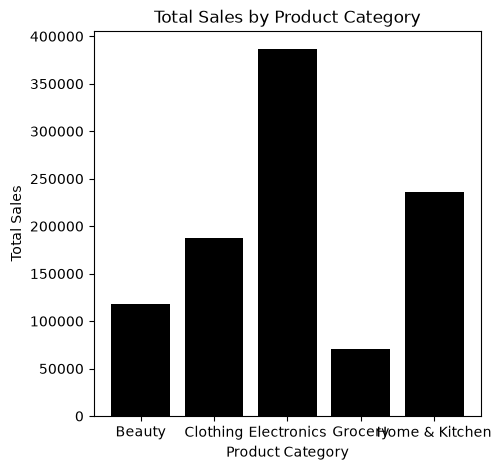

In [56]:
#7.
plt.figure(figsize=(5, 5))

plt.bar(
    category_sales.index,
    category_sales.values,
    color="black"      
)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

Region
North    40
South    38
West     37
East     35
Name: count, dtype: int64


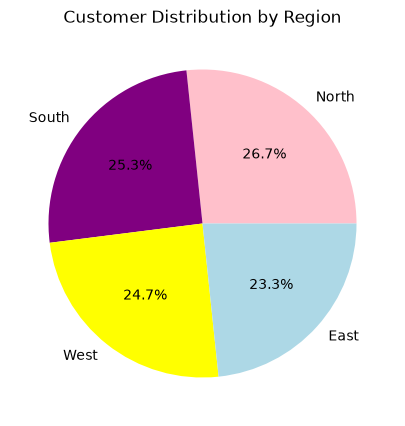

In [ ]:
#8.
region_customers = df["Region"].value_counts()

print(region_customers)

plt.figure(figsize=(10, 5))

plt.pie(
    region_customers.values,
    labels=region_customers.index,
    autopct="%1.1f%%",
    colors=[
        "pink",
        "purple",
        "yellow",
        "lightblue"]
)

plt.title("Customer Distribution by Region")

plt.show()

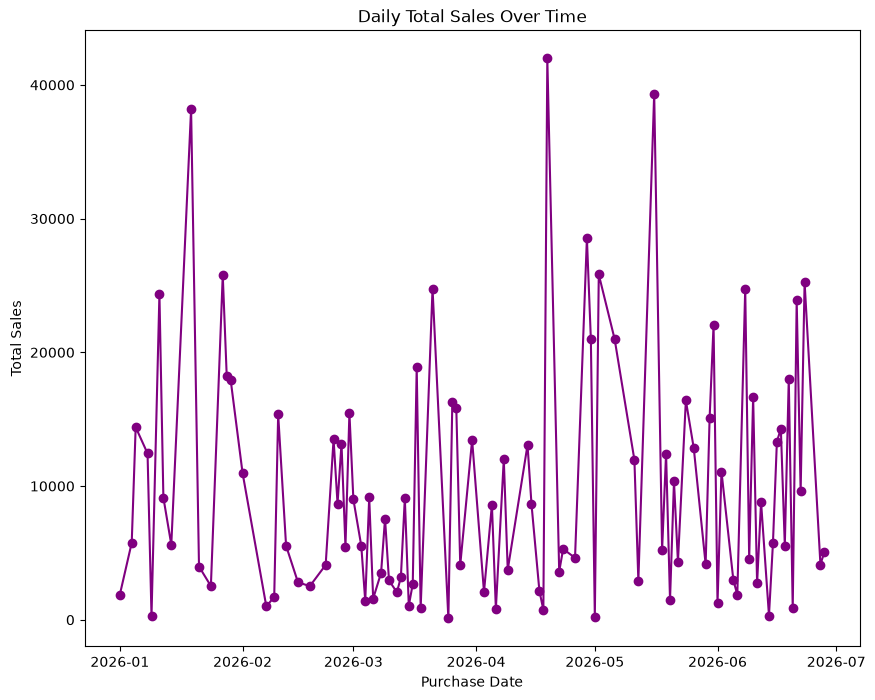

In [58]:
#9.
daily_sales = df.groupby("Purchase_Date")["Total_Amount"].sum()

plt.figure(figsize=(10, 8))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    marker="o",
    color="purple"
    
)

plt.title("Daily Total Sales Over Time")

plt.xlabel("Purchase Date")

plt.ylabel("Total Sales")

plt.show()

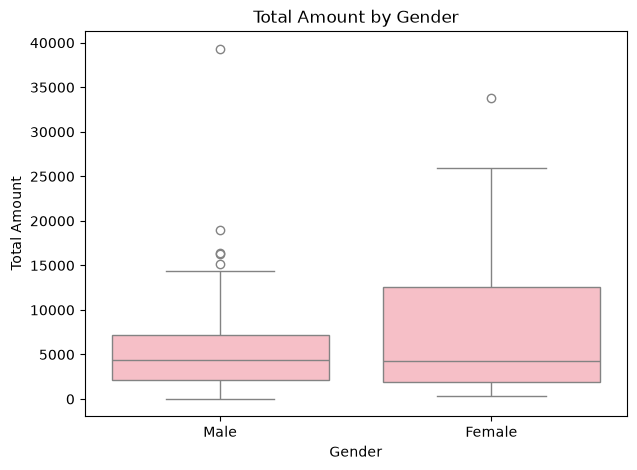

In [59]:
#10.
plt.figure(figsize=(7 , 5))

sns.boxplot(
  x="Gender",
  y = "Total_Amount",
  data = df,
  color="lightpink"
)

plt.title("Total Amount by Gender")

plt.xlabel("Gender")
plt.ylabel("Total Amount")

plt.show()

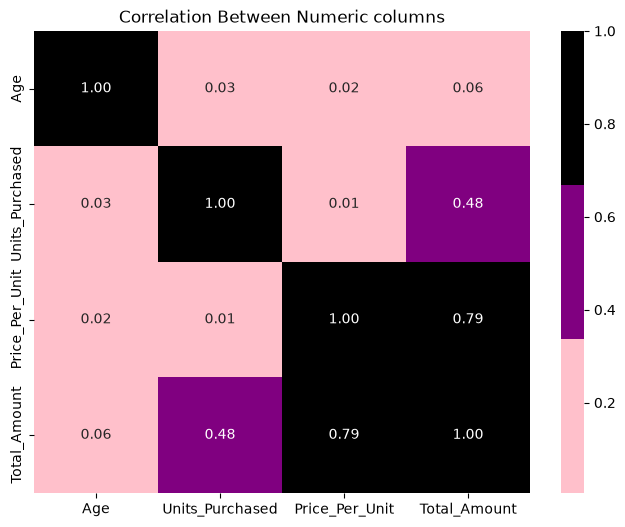

In [64]:
#10.
numeric_columns = df.select_dtypes(include=np.number)

correlation = numeric_columns.corr()


plt.figure(figsize=(8 , 6))

sns.heatmap(
  correlation,
  annot=True,
  cmap=["pink","purple","black"],
  fmt=".2f"
)
plt.title("Correlation Between Numeric columns")

plt.show()
